[![Open In Colab](./colab-badge.png)](https://colab.research.google.com/github/MooseNeuro/moose-notebooks/blob/main/Branching_neurites.ipynb) [![Binder](./binder_logo.png)](https://mybinder.org/v2/gh/MooseNeuro/moose-notebooks/HEAD?labpath=Branching_neurites.ipynb)

In [1]:
## Only required on colab! Uncomment to enable.
# !pip install pymoose --quiet

# Branching neurites

In the [Cable theory](Cable_theory.ipynb) notebook we saw how electrical signals decay with distance in a uniform, linear, passive neurite. Real neuronal cells, however, look like trees with many branches. Neurons have "dendrites", a word derived from "dendron", Greek word for tree.

How can we analyze and understand signal propagation through real neurons? They turn out to be too complex for analytical solutions. [Wilfrid Rall](https://en.wikipedia.org/wiki/Wilfrid_Rall) came up with a method to simulate them using numerical methods on computers. This is called compartmental modelling.

## Compartmental modelling

The [Cable theory](Cable_theory.ipynb) notebook approximated the cylindrical cable with sequentially connected compartments with identical passive properties. This is essentially dividing length into small sections and solving the system of ordinary differential equations for all the sections.

A segment of neurite that is electrotonically short is assumed to be ispotential, and represented as a lumped RC circuit. To our advantage, this approach works even for non-uniform neurites, where the diameter, specific resistance, or other properties vary by location.


## Simple branched structures
### A Y branch with 3 compartments
We can start by making a Y shaped neuron in moose

In [2]:
# Usual imports
import numpy as np
import matplotlib.pyplot as plt

import moose

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


In [3]:
# Create containers
container = moose.Neutral('/sim')
data = moose.Neutral('/sim/data')
model = moose.Neutral('/sim/model')

#### Creating a Y shaped morphology
We will create the trunk of the dendrite called `dendrite`, and connect two branches `branch_0` and `branch_1` to this. The connection is done via `axial`-`raxial` messages.

In [4]:
dendrite = moose.Compartment(f'{model.path}/dendrite')
branch_a = moose.Compartment(f'{model.path}/branch_a')
branch_b = moose.Compartment(f'{model.path}/branch_b')

moose.connect(dendrite, 'raxial', branch_a, 'axial')
moose.connect(dendrite, 'raxial', branch_b, 'axial')

<moose.SingleMsg path=/Msgs[0]/singleMsg[1] id=5 dataIndex=1 fieldIndex=0>

#### Setting up current stimulus
We also create a pulse-generator to inject a step current into the trunk of the dendrite.


In [5]:
stim = moose.PulseGen(f'{model.path}/stim')
moose.connect(stim, 'output', dendrite, 'injectMsg')

<moose.SingleMsg path=/Msgs[0]/singleMsg[2] id=5 dataIndex=2 fieldIndex=0>

#### Data recording setup

Now we create the data tables under '/sim/data' (the `data` element) to record the membrane voltage of the compartments. We use an `f-string` expression to name the tables after the corresponding compartment-name with a "vm_" prefix.

In [6]:
comps = (dendrite, branch_a, branch_b)
vm_tabs = []
for comp in comps:
    vm_tab = moose.Table(f'{data.path}/vm_{comp.name}')
    moose.connect(vm_tab, 'requestOut', comp, 'getVm')
    vm_tabs.append(vm_tab)

#### Passive properties from specific values
The passive properties of all the compartments are set identically. Note that we are setting absolute values of `Rm`, `Ra`, and `Cm`. Although the `Compartment` class has `length` and `diameter` attributes, these are used for visualizing the neuronal morphology, not in the computation. When you have specific values for `RM`, `RA`, and `CM`, you have to convert these to absolute values assuming the compartment to be a cylinder.

Let us assume uniform specific properties, RM=10 $k\Omega\, cm^{2}$, CM=1 $\mu F/cm^{2}$, and RA=0.1 $k\Omega\, cm$. 

In SI these become RM=1 $\Omega\, m^2$, CM=0.01 $F/cm^{2}$, and RA=1 $\Omega\, m$.

We also assume that each compartment has length 5 $\mu m$ and diameter 1 $\mu m$.

In [7]:
# Specific values of the passive properties
RM = 1.0   # Specific membrane resistance
CM = 0.01  # Specific membrane capacitance
RA = 1.0   # Specific cytoplasmic/axial resistance

length = 5e-6
dia = 1e-6

# Surface area of each compartment 
sarea = np.pi * dia * length
# Area of cross section: axial resistance is inversely proportional to this
xarea = np. pi * dia * dia / 4

# Absolute values of the passive properties
Rm = RM / sarea
Cm = CM * sarea
Ra = RA * length / xarea

# Set the passive properties of all the compartments
for comp in comps:
    comp.initVm = -70e-3
    comp.Em = -70e-3  
    comp.Rm = Rm
    comp.Cm = Cm
    comp.Ra = Ra

#### Setting up the stimulus protocol
We will inject 0.2 $nA$ current through the `PulseGen` for 10 $ms$ starting at 5 $ms$.

In [8]:
stim.delay[0] = 5e-3
stim.width[0] = 10e-3
stim.level[0] = 0.2e-9
stim.delay[1] = 1e10   # delay the second pulse beyond likely simulation duration

#### *Note on order of doing things in MOOSE*
*We could have set the passive properties of the compartments right after creating them. However we kept all the code for creating and connecting the objects in the beginning, and put all the attribute settings at the end. There is a reason for this.*

*Whenever you call `moose.connect(...)`, it creates a new connection, so that multiple connect calls on the same pair of objects and fields will create multiple connections between them. During the simulation, messages will be passed through each of these connections sequentially at each timestep. For example, if you connect `vm_tab` to `comp` twice, in each timestep `vm_tab` will get two copies of `comp.Vm`, and the length of `vm_tab.vector` will be double. Thus we want to run the code defining the structure of the model only once.*

*However, for our simulation experiments we want to modify the parameters and rerun the simulation again and again in an interactive setting. Thus, in jupyter notebook it is convenient and safer to have the code for setting frequently changed parameters close to the code for initializing and running the simulation.*

#### Initialize and run the simulation

In [9]:
simtime = 50e-3   # run for 50 ms

moose.reinit()
moose.start(simtime)

#### Plot the data

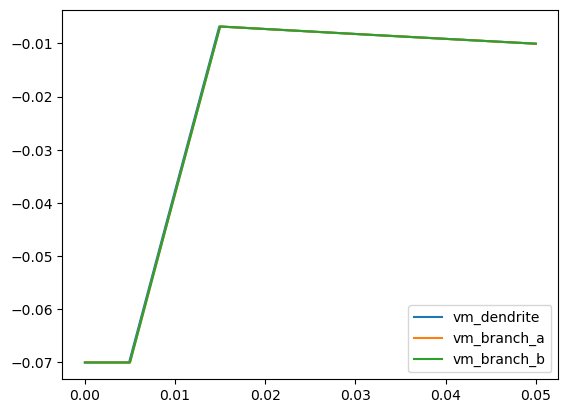

In [10]:
fig, ax = plt.subplots()
t = np.arange(len(vm_tabs[0].vector)) * vm_tabs[0].dt
for tab in vm_tabs:
    ax.plot(t, tab.vector, label=tab.name)
ax.legend()

#### Interpreting the results
With the given passive properties (RM=10 $k\Omega\, cm^{2}$, CM=1 $\mu F/cm^{2}$, and RA=0.1 $k\Omega\, cm$, length=5 $\mu m$ and diameter=1 $\mu m$ for each compartment), the voltage plots should be practically overlapping. Thus there is very little change in the voltage from compartment to compartment.

#### Exercises
1. Now increase RA 100 fold, then 1000 fold, and rerun the simulation and see how the plots change.
2. Keeping the specific properties same, increase the length of each compartment to 50 $\mu m$ and rerun the simulation. What do you observe?

### Making a longer Y branch model with more segments
Now let us take the case when each branch of our neuron is 50 $\mu m$ long, and split each branch into 10 compartments (i.e., 10 compartments of 5 $\mu m$ length each.

#### Delete the old model and make new containers

We can start by deleting the first model, and recreating the containers. We could also create a new model in parallel in a different container, but that would mean both models will get simulated simultaneously, wasting computer time.

In [11]:
# Delete old model
moose.delete(container)

True

In [12]:
# Create containers
container = moose.Neutral('/sim')
data = moose.Neutral('/sim/data')
model = moose.Neutral('/sim/model')

#### Create the linear branches 
For each branch of the Y we will create 10 compartments. We are using `list comprehension` in Python to keep the code short. This is essentially a compressed `for loop`.

In [13]:
# Number of compartment in each branch is 10
ncomp = 10

# Use list comprehension to create segments
dendrite = [moose.Compartment(f'{model.path}/dend_{ii}') for ii in range(ncomp)]
branch_a = [moose.Compartment(f'{model.path}/branch_a_{ii}') for ii in range(ncomp)]
branch_b = [moose.Compartment(f'{model.path}/branch_b_{ii}') for ii in range(ncomp)]


We will connect the compartments within each branch using a `for loop`, but put it inside another `for loop` going over each branch.

In [14]:
for branch in (dendrite, branch_a, branch_b):
    for ii in range(1, len(branch)):
        prev = branch[ii-1]  # previous compartment, starting at 0
        curr = branch[ii]    # current compartment, starting at 1
        moose.connect(prev, 'raxial', curr, 'axial')

Finally we must connect the end of the `dendrite` to the start of the branches `branch_a` and `branch_b`.

In [15]:
moose.connect(dendrite[-1], 'raxial', branch_a[0], 'axial')
moose.connect(dendrite[-1], 'raxial', branch_b[0], 'axial')

<moose.SingleMsg path=/Msgs[0]/singleMsg[34] id=5 dataIndex=34 fieldIndex=0>

#### Setting up current stimulus
We also create a pulse-generator to inject a step current into the trunk of the dendrite. Note that now we are connecting the `PulseGen`'s output to `dendrite[0]`, the first compartment in the dendrite.


In [16]:
stim = moose.PulseGen(f'{model.path}/stim')
moose.connect(stim, 'output', dendrite[0], 'injectMsg')

<moose.SingleMsg path=/Msgs[0]/singleMsg[35] id=5 dataIndex=35 fieldIndex=0>

#### Data recording setup

This time we will record data at the following locations: the dendrite compartment where we are injecting the stimulus, the dendrite compartment where the two branches are attached, and the first and last compartments of the two branches.

In [17]:
comps = (dendrite[0], dendrite[-1], branch_a[0], branch_b[0], branch_a[-1], branch_b[-1])
vm_tabs = []
for comp in comps:
    vm_tab = moose.Table(f'{data.path}/vm_{comp.name}')
    moose.connect(vm_tab, 'requestOut', comp, 'getVm')
    vm_tabs.append(vm_tab)

#### Setting the passive properties
We will set the passive properties of all the compartments just like before. 

*Side note on Python: we are concatenating the three lists of compartments by using the `+` operator to loop through all the compartments.*

In [18]:
# Specific values of the passive properties
RM = 1.0   # Specific membrane resistance
CM = 0.01  # Specific membrane capacitance
RA = 1.0   # Specific cytoplasmic/axial resistance

length = 5e-6
dia = 1e-6

# Surface area of each compartment 
sarea = np.pi * dia * length
# Area of cross section: axial resistance is inversely proportional to this
xarea = np. pi * dia * dia / 4

# Absolute values of the passive properties
Rm = RM / sarea
Cm = CM * sarea
Ra = RA * length / xarea

# Set the passive properties of all the compartments
# Note that adding lists in Python concatenates them
for comp in dendrite + branch_a + branch_b:
    comp.initVm = -70e-3
    comp.Em = -70e-3  
    comp.Rm = Rm
    comp.Cm = Cm
    comp.Ra = Ra

#### Setting up the stimulus protocol
Like before, we will inject 0.2 $nA$ current through the `PulseGen` for 10 $ms$ starting at 5 $ms$.

In [19]:
stim.delay[0] = 5e-3
stim.width[0] = 10e-3
stim.level[0] = 0.2e-9
stim.delay[1] = 1e10   # delay the second pulse beyond likely simulation duration

#### Initialize and run the simulation

In [20]:
simtime = 50e-3   # run for 50 ms

moose.reinit()
moose.start(simtime)

#### Plot the data
Like before, we have all the tables in the `vm_tabs` list, and we will loop through it to plot the data.

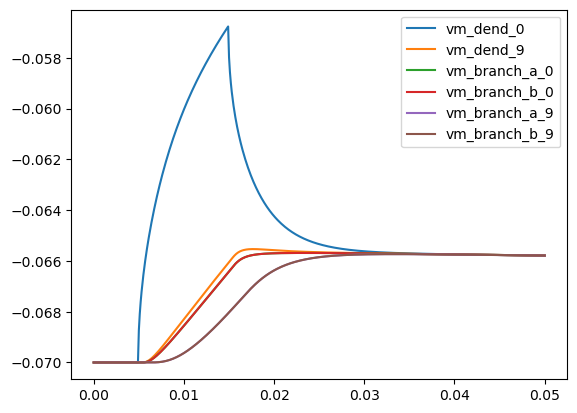

In [21]:
fig, ax = plt.subplots()
t = np.arange(len(vm_tabs[0].vector)) * vm_tabs[0].dt
for tab in vm_tabs:
    ax.plot(t, tab.vector, label=tab.name)
ax.legend()

#### Exercise
1. Why do you not see the graphs `vm_branch_a_0` and `vm_branch_a_9`? What is the physical reason for this?
2. Change the diameter for one of the branches (say `branch_b`)to 0.1 $\mu m$ and rerun the simulation. What do you observe now? Explain the results.